=== Classification Report ===
              precision    recall  f1-score   support

       Hello       1.00      0.76      0.86        29
    IloveYou       1.00      0.73      0.85        30
          No       1.00      0.65      0.79        34
      Please       1.00      0.58      0.73        26
      Thanks       1.00      0.68      0.81        34
         Yes       1.00      0.78      0.88        32

   micro avg       1.00      0.70      0.82       185
   macro avg       1.00      0.70      0.82       185
weighted avg       1.00      0.70      0.82       185



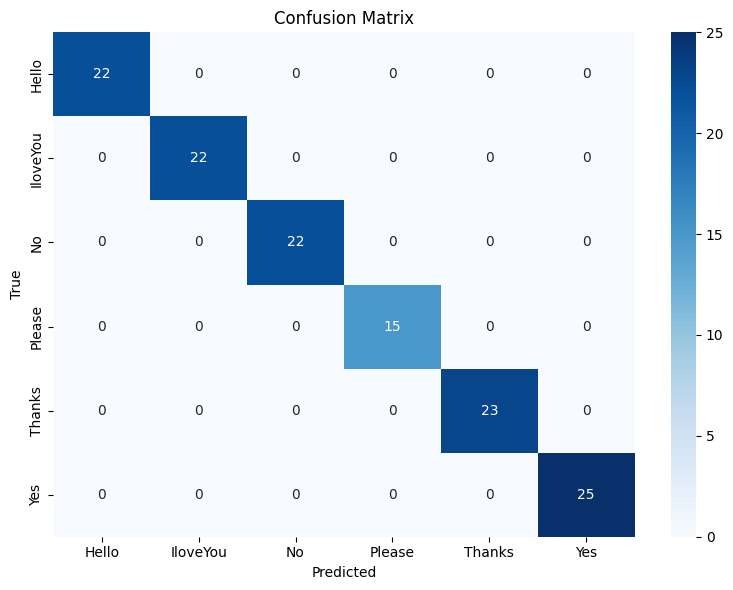

✅ Ví dụ đúng: Hello


❌ Ví dụ sai: Hello


✅ Ví dụ đúng: IloveYou


❌ Ví dụ sai: IloveYou


✅ Ví dụ đúng: No


...

❌ Ví dụ sai: Please


✅ Ví dụ đúng: Thanks


❌ Ví dụ sai: Thanks


✅ Ví dụ đúng: Yes


❌ Ví dụ sai: Yes


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display, Image, HTML
import random

# Nhãn cử chỉ
class_names = ['Hello', 'IloveYou', 'No', 'Please', 'Thanks', 'Yes']

# Đường dẫn ảnh test
test_dir = './Data/test/images'  # Thay nếu thư mục khác

# Load mô hình YOLO
model = YOLO('best.pt')  # Thay nếu mô hình ở nơi khác

# Tạo thư mục lưu ảnh định tính
correct_dir = './output/correct'
incorrect_dir = './output/incorrect'
for cname in class_names:
    os.makedirs(os.path.join(correct_dir, cname), exist_ok=True)
    os.makedirs(os.path.join(incorrect_dir, cname), exist_ok=True)

# Hàm làm nhiễu ảnh
def distort_image(image):
    # Làm mờ
    blurred = cv2.GaussianBlur(image, (9, 9), 0)

    # Xoay nhẹ
    h, w = blurred.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), 15, 1.0)
    rotated = cv2.warpAffine(blurred, M, (w, h))

    # Thêm noise
    noise = np.random.normal(0, 25, rotated.shape).astype(np.uint8)
    distorted = cv2.add(rotated, noise)

    return distorted

# Chuẩn bị dữ liệu
y_true = []
y_pred = []

# Chọn ngẫu nhiên 30% ảnh sẽ bị nhiễu
all_filenames = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
distort_count = int(0.3 * len(all_filenames))
distorted_set = set(random.sample(all_filenames, distort_count))

# Duyệt qua ảnh test
for fname in all_filenames:
    true_label = next((c for c in class_names if fname.lower().startswith(c.lower())), None)
    if true_label is None:
        continue

    img_path = os.path.join(test_dir, fname)
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Gây nhiễu nếu nằm trong distorted_set
    input_img = distort_image(img) if fname in distorted_set else img

    results = model.predict(source=input_img, conf=0.25, verbose=False)
    pred_label = (
        results[0].names[int(results[0].boxes.cls[0])]
        if results[0].boxes else "No Detection"
    )

    y_true.append(true_label)
    y_pred.append(pred_label)

    # Annotate ảnh để lưu
    annotated_img = results[0].plot()
    save_path = os.path.join(
        correct_dir if pred_label == true_label else incorrect_dir,
        true_label,
        fname
    )
    cv2.imwrite(save_path, annotated_img)

# In báo cáo định lượng
print("=== Classification Report ===")
print(classification_report(
    y_true, y_pred, labels=class_names, target_names=class_names, zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=class_names)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('./output/confusion_matrix.png')
plt.show()

# Hiển thị ảnh định tính
def show_images(folder, label, count=3):
    folder_path = os.path.join(folder, label)
    if not os.path.exists(folder_path):
        print(f'Không tìm thấy thư mục {folder_path}')
        return

    files = os.listdir(folder_path)[:count]
    images_html = ''
    for f in files:
        image_path = os.path.join(folder_path, f)
        images_html += f'<img src="files/{image_path}" width="200" style="margin: 5px;">'
    display(HTML(images_html))

for gesture in class_names:
    print(f'✅ Ví dụ đúng: {gesture}')
    show_images(correct_dir, gesture)

    print(f'❌ Ví dụ sai: {gesture}')
    show_images(incorrect_dir, gesture)


In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from math import ceil

# Nhãn cử chỉ
class_names = ['Hello', 'IloveYou', 'No', 'Please', 'Thanks', 'Yes']
correct_dir = './output/correct'
incorrect_dir = './output/incorrect'
save_dir = './qualitative_samples'
os.makedirs(save_dir, exist_ok=True)

# Hàm tạo 1 ảnh grid và lưu
def create_grid_image(images, title, save_path, n_cols=4):
    n_images = len(images)
    if n_images == 0:
        print(f"⚠ Không có ảnh cho {title}")
        return

    n_rows = ceil(n_images / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
    fig.suptitle(title, fontsize=14)

    # Đảm bảo axes là mảng
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = np.array(axes).reshape(n_rows, n_cols)
    else:
        axes = np.array(axes)

    axes = axes.flatten()

    for i in range(n_rows * n_cols):
        ax = axes[i]
        if i < n_images:
            img = cv2.imread(images[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig(save_path)
    plt.close()
    print(f"✅ Đã lưu: {save_path}")

# Tạo 12 ảnh
for idx, label in enumerate(class_names):
    # Ảnh đúng
    correct_path = os.path.join(correct_dir, label)
    correct_imgs = [os.path.join(correct_path, f) for f in os.listdir(correct_path) if f.lower().endswith(('.jpg', '.png'))]
    create_grid_image(
        images=correct_imgs,
        title=f"{label} – Correct",
        save_path=os.path.join(save_dir, f"image_{idx*2+1:02d}_{label.lower()}_correct.png")
    )

    # Ảnh sai
    incorrect_path = os.path.join(incorrect_dir, label)
    incorrect_imgs = [os.path.join(incorrect_path, f) for f in os.listdir(incorrect_path) if f.lower().endswith(('.jpg', '.png'))]
    create_grid_image(
        images=incorrect_imgs,
        title=f"{label} – Incorrect",
        save_path=os.path.join(save_dir, f"image_{idx*2+2:02d}_{label.lower()}_incorrect.png")
    )


✅ Đã lưu: ./qualitative_samples\image_01_hello_correct.png
✅ Đã lưu: ./qualitative_samples\image_02_hello_incorrect.png
✅ Đã lưu: ./qualitative_samples\image_03_iloveyou_correct.png
✅ Đã lưu: ./qualitative_samples\image_04_iloveyou_incorrect.png
✅ Đã lưu: ./qualitative_samples\image_05_no_correct.png
✅ Đã lưu: ./qualitative_samples\image_06_no_incorrect.png
✅ Đã lưu: ./qualitative_samples\image_07_please_correct.png
✅ Đã lưu: ./qualitative_samples\image_08_please_incorrect.png
✅ Đã lưu: ./qualitative_samples\image_09_thanks_correct.png
✅ Đã lưu: ./qualitative_samples\image_10_thanks_incorrect.png
✅ Đã lưu: ./qualitative_samples\image_11_yes_correct.png
✅ Đã lưu: ./qualitative_samples\image_12_yes_incorrect.png
